In [1]:
import os
import sys
lib_path = os.path.abspath(os.path.join(os.path.abspath(''), 'functions/'))
sys.path.append(lib_path)
# need to append our functions dir to the path! 

import SD_raster_loading
import SD_NC_loading
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dalecLoad
import spectralConv
import seaborn as sns
import scipy as sp
from datetime import timedelta
import matplotlib.dates as mdates

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV

In [2]:
def MAE(true, pred):
    return np.sum(np.abs(true - pred))/len(pred)
def MAPE(true, pred):
    return 100 * np.sum(np.abs((true - pred)/true))/len(pred)
def RMSE(true, pred):
    return np.sqrt(np.sum((true - pred)**2)/len(pred))

def RMSD(y_true, y_est):
    '''
    logspace RMSE
    '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**(np.sqrt(np.mean((y_true - y_est)**2)))-1

def MAD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the mean absolute difference (MAD) '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**np.mean(np.abs(y_true - y_est))-1

def MAvD(y_true, y_est):
    '''mean average differnce - bias'''
    return np.sum((y_est - y_true)/len(y_est))

def MAPD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median absolute percentage difference (MAPD) '''
    return np.nanmedian(np.abs((y_true - y_est) / y_true)) * 100


def MDSA(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median symmetric accuracy (MdSA) '''
    return (np.exp(np.nanmedian(np.abs(np.log(y_est / y_true)))) - 1) * 100


def SSPB(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the symmetric signed percentage bias (SSPB) '''
    med = np.nanmedian( np.log(y_est / y_true) )
    return np.sign(med) * (np.exp(np.abs(med)) - 1) * 100

def MRD(true, pred):
    '''mean relative difference'''
    return np.sum(((pred - true)/true)) / len(pred)

In [3]:
def p_sig(p_val):
    if p_val >= 0.05:
        return '(ns)'
    elif p_val >= 0.01:
        return '*'
    elif p_val >= 0.001:
        return '**'
    else:
        return '***'

In [4]:
coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
# coord = [56.147005, -3.923147] # this is approx the location of the DALEC + ~20 m out which looks less edge effected 

#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_acolite = SD_NC_loading.load_multiple_SDs('S2_downloads/acolite_output/',
                                        coord, skipSameDay=False,
                                        pixel_grid_shape=(3,3),
                                        filetype="L2R.nc",
                                        variable='rhos',
                                        div_by_pi=True,)

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [5]:
# coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_c2rcc = SD_NC_loading.load_multiple_SDs('C2RCC/full_S2_c2rcc_all_valid/',
                                            coord, skipSameDay=False,
                                            pixel_grid_shape=(3,3),
                                            filetype=".nc",
                                            variable='rrs',
                                            date_name='start_date',
                                            wavelengths_S2A=[443., 492., 560., 665., 704., 740., 783., 865.],
                                            wavelengths_S2B=[442., 492., 559., 665., 704., 739., 780., 864.],
                                            div_by_pi=False,)

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best doub

In [6]:
# coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_c2rcc_CX = SD_NC_loading.load_multiple_SDs('C2RCC/full_S2_c2rcc_complex_X/',
                                            coord, skipSameDay=False,
                                            pixel_grid_shape=(3,3),
                                            filetype=".nc",
                                            variable='rrs',
                                            date_name='start_date',
                                            wavelengths_S2A=[443., 492., 560., 665., 704., 740., 783., 865.],
                                            wavelengths_S2B=[442., 492., 559., 665., 704., 739., 780., 864.],
                                            div_by_pi=False,)

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best doub

In [7]:
# coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_c2rcX = SD_NC_loading.load_multiple_SDs('C2RCC/full_s2_c2rcc_c2X_all_valid_salin03/',
                                            coord, skipSameDay=False,
                                            pixel_grid_shape=(3,3),
                                            filetype=".nc",
                                            variable='rrs',
                                            date_name='start_date',
                                            wavelengths_S2A=[443., 492., 560., 665., 704., 740., 783., 865.],
                                            wavelengths_S2B=[442., 492., 559., 665., 704., 739., 780., 864.],
                                            div_by_pi=False,)

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

In [8]:
# coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_polymer = SD_NC_loading.load_multiple_SDs('Polymer/polymer_S2_full_out/',
                                            coord, skipSameDay=False,
                                            pixel_grid_shape=(3,3),
                                            filetype=".nc",
                                            variable='Rw',
                                            date_name='start_time',
                                            wavelengths_S2A=[443., 492., 560., 665., 704., 740.,
                                                             783., 833., 865., 1610.],
                                            wavelengths_S2B=[442., 492., 559., 665., 704., 739.,
                                                             780., 833., 864., 1610.],
                                            div_by_pi=True,
                                            lat_name='latitude',
                                            lon_name='longitude')

are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 

are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 

are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [9]:
S2_c2rcc

rho_s_20_29    rho_s_20_30  \
Date                       Wavelength                                 
2022-03-01 11:43:49.023999 442.0       0.00017024323  0.00016392928   
                           492.0       0.00023567966  0.00022119387   
                           559.0       0.00049106515  0.00043538783   
                           665.0       0.00066173915  0.00055585604   
                           704.0          0.00060515   0.0005040837   
...                                              ...            ...   
2023-10-29 11:33:19.023999 665.0       0.00022225303  0.00011272793   
                           704.0       0.00013017732  6.3287654e-05   
                           739.0       3.4560802e-05   1.645065e-05   
                           780.0       3.1356583e-05  1.4458377e-05   
                           864.0       1.1902975e-05   5.246491e-06   

                                         rho_s_20_31    rho_s_21_29  \
Date                       Wavelength                                 
2022-03-01 11:43:49.023999 442.0       0.00023340198  0.00022518486   
                           492.0       0.00030851527  0.00031195153   
                           559.0       0.00059372134   0.0006590573   
                           665.0        0.0006917495   0.0006365695   
                           704.0        0.0006220646  0.00053914706   
...                                              ...            ...   
2023-10-29 11:33:19.023999 665.0       0.00014111915  0.00016495428   
                           704.0        7.948944e-05  9.6319214e-05   
                           739.0       2.0854157e-05  2.5519632e-05   
                           780.0       1.8538318e-05   2.276669e-05   
                           864.0         6.87658e-06   8.458577e-06   

                                         rho_s_21_30    rho_s_21_31  \
Date                       Wavelength                                 
2022-03-01 11:43:49.023999 442.0       0.00027136874  0.00018606625   
                           492.0       0.00037157442  0.00025809158   
                           559.0        0.0007647245  0.00054202473   
                           665.0        0.0007560488   0.0005478217   
                           704.0       0.00064884423  0.00045765433   
...                                              ...            ...   
2023-10-29 11:33:19.023999 665.0        0.0001260353  0.00010595786   
                           704.0         7.09215e-05    5.90732e-05   
                           739.0        1.856062e-05   1.530785e-05   
                           780.0        1.641236e-05  1.3424181e-05   
                           864.0        6.031674e-06   4.855308e-06   

                                         rho_s_22_29     rho_s_22_30  \
Date                       Wavelength                                  
2022-03-01 11:43:49.023999 442.0       0.00026476898    0.0002434997   
                           492.0       0.00037199276    0.0003498981   
                           559.0       0.00081366964   0.00079502614   
                           665.0       0.00070742925    0.0006506636   
                           704.0        0.0005973172   0.00053161796   
...                                              ...             ...   
2023-10-29 11:33:19.023999 665.0        0.0001848322   0.00020869674   
                           704.0       0.00010595302  0.000119519216   
                           739.0       2.8082517e-05   3.1910113e-05   
                           780.0       2.5324412e-05    2.893093e-05   
                           864.0        9.574363e-06   1.1055882e-05   

                                         rho_s_22_31  
Date                       Wavelength                 
2022-03-01 11:43:49.023999 442.0       0.00018332509  
                           492.0        0.0002618627  
                           559.0        0.0005821465  
                           665.0        0.0005185053  
  

In [100]:
# useful for interrogating the ncdf file (eg. to find the name we want to use for the date)
f = netCDF4.Dataset('Polymer/polymer_S2_full_out/resubset_S2A_MSIL2_20220306T114351_N0400_R123_T30VVH_20220306T135207_polymerL2.nc')
# SD_spect = get_SD_NC_Spectra_grid(f, coord[0], coord[1], shape=pixel_grid_shape,
#                                   variable=variable, wavelengths=wavelengths)
f

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dir_base: /home/lion/Documents/StirlingUni/Project/polymer/polymer-master
    sensor: MSI
    dir_common: /home/lion/Documents/StirlingUni/Project/polymer/polymer-master/auxdata/common/
    thres_Rcloud: 0.2
    thres_Rcloud_std: 0.04
    force_initialization: False
    reinit_rw_neg: False
    max_iter: 100
    size_end_iter: 0.005
    metrics: W_dR2_norm
    glint_precorrection: True
    external_mask: None
    lut_file: /home/lion/Documents/StirlingUni/Project/polymer/polymer-master/auxdata/generic/LUT.hdf
    thres_chi2: 0.005
    partial: 0
    weights_corr: None
    weights_oc: None
    atm_model: T0,-1,Rmol
    normalize: 3
    Rprime_consistency: True
    water_model: PR05
    initial_point_1: [-1, 0]
    initial_point_2: [1, 1]
    initial_points: [[]]
    initial_step: [0.2, 0.2]
    firstguess_method: 1
    bounds: [[-2, 2], [-3, 3]]
    constraint_logfb: [0.0001, 0.2258, 0.9233]
    bb

In [10]:
idpix_flags = SD_NC_loading.load_multiple_IDEPIXs('Polymer/idepix_subset_resample_full_s2/',
                                                  coord, pixel_grid_shape=(3, 3))

In [102]:
idpix_flags

,IDEPIX_flag20_29,IDEPIX_flag20_30,IDEPIX_flag20_31,IDEPIX_flag21_29,IDEPIX_flag21_30,IDEPIX_flag21_31,IDEPIX_flag22_29,IDEPIX_flag22_30,IDEPIX_flag22_31
Date,,,,,,,,,
2022-03-01 11:43:49.023999,541696,541696,541696,541696,541696,541696,541696,541696,541696
2022-03-06 11:43:51.023999,148480,148480,17408,17408,17408,17408,17408,17408,17408
2022-03-08 11:33:19.024000,148480,17408,17408,17408,17408,17408,17408,17408,17408
2022-03-21 11:43:49.023999,664576,672768,541696,541696,541696,541696,541696,541696,541696
2022-03-23 11:33:21.025000,140288,140288,140288,140288,140288,140288,140288,140288,140288
...,...,...,...,...,...,...,...,...,...
2023-10-19 11:33:19.023999,203914,203914,203914,203914,203914,203914,203914,203914,203914
2023-10-22 11:43:49.023999,672768,148480,148480,672768,17408,17408,541696,17408,17408
2023-10-24 11:33:21.023999,203914,203914,203914,203914,203914,203914,203914,203914,203914


In [11]:
# I think for now, we'll only care about the following flags:

# IDEPIX_INVALID IDEPIX_CLOUD IDEPIX_CLOUD_AMBIGUOUS IDEPIX_CLOUD_SURE

# IDEPIX_CLOUD_BUFFER IDEPIX_CLOUD_SHADOW IDEPIX_SNOW_ICE IDEPIX_BRIGHT IDEPIX_WHITE

# so this is the first 10 flags 

# in binary that's 0b1111111111


# then add a few more which might cause issues:

# CIRRUS_SURE: 2048
# CIRRUS AMBIGIOUS: 4096
# BRIGHT_WHITE: 65536
# CLUSTERED_CLOUD_SHADOW: 1048576
# IDEPIX POTENTIAL SHADOW: 524288

flag_mask  = 0b1111111111 + 2048 + 4096 + 65536 + 1048576 #+ 524288
flag_mask

1121279

In [12]:
# this confused me when I came back to it
# so it works that if flag_mask and idpix_flags have no bits in common then the bitwise and output will be 0
# 0 == False, therefore df_good data is the data with no problem flags
df_good_data = idpix_flags & flag_mask
df_good_data = df_good_data[df_good_data==False]

In [13]:
df_good_data = df_good_data.reset_index()
df_good_data['date'] = df_good_data.Date.dt.date

In [14]:
good_dates = df_good_data.dropna().date.unique()
good_dates

array([datetime.date(2022, 3, 1), datetime.date(2022, 3, 6),
       datetime.date(2022, 3, 8), datetime.date(2022, 3, 21),
       datetime.date(2022, 3, 23), datetime.date(2022, 3, 26),
       datetime.date(2022, 3, 28), datetime.date(2022, 4, 20),
       datetime.date(2022, 4, 22), datetime.date(2022, 6, 4),
       datetime.date(2022, 7, 1), datetime.date(2022, 7, 4),
       datetime.date(2022, 7, 16), datetime.date(2022, 7, 29),
       datetime.date(2022, 8, 10), datetime.date(2022, 8, 20),
       datetime.date(2022, 9, 12), datetime.date(2022, 9, 14),
       datetime.date(2023, 3, 1), datetime.date(2023, 3, 6),
       datetime.date(2023, 3, 8), datetime.date(2023, 3, 11),
       datetime.date(2023, 4, 7), datetime.date(2023, 4, 15),
       datetime.date(2023, 4, 20), datetime.date(2023, 4, 22),
       datetime.date(2023, 5, 15), datetime.date(2023, 5, 22),
       datetime.date(2023, 5, 25), datetime.date(2023, 5, 30),
       datetime.date(2023, 6, 4), datetime.date(2023, 6, 9),
    

In [15]:
S2_c2rcc = S2_c2rcc.reset_index()
S2_c2rcc['date'] = S2_c2rcc.Date.dt.date
S2_c2rcc_CX = S2_c2rcc_CX.reset_index()
S2_c2rcc_CX['date'] = S2_c2rcc_CX.Date.dt.date
S2_c2rcX = S2_c2rcX.reset_index()
S2_c2rcX['date'] = S2_c2rcX.Date.dt.date
S2_acolite = S2_acolite.reset_index()
S2_acolite['date'] = S2_acolite.Date.dt.date
S2_polymer = S2_polymer.reset_index()
S2_polymer['date'] = S2_polymer.Date.dt.date

In [16]:
S2_c2rcc = S2_c2rcc[S2_c2rcc.date.isin(good_dates)]
S2_acolite = S2_acolite[S2_acolite.date.isin(good_dates)]
S2_polymer = S2_polymer[S2_polymer.date.isin(good_dates)]
S2_c2rcX = S2_c2rcX[S2_c2rcX.date.isin(good_dates)]
S2_c2rcc_CX = S2_c2rcc_CX[S2_c2rcc_CX.date.isin(good_dates)]

In [17]:
S2_c2rcc_CX_melt = pd.melt(S2_c2rcc_CX, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
S2_c2rcc_melt = pd.melt(S2_c2rcc, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
S2_c2rcX_melt = pd.melt(S2_c2rcX, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
S2_acolite_melt = pd.melt(S2_acolite, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
S2_polymer_melt = pd.melt(S2_polymer, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')

In [18]:
S2_c2rcc_melt

,Date,date,Wavelength,location,Rrs
0,2022-03-01 11:43:49.023999,2022-03-01,442.0,rho_s_20_29,0.00017024323
1,2022-03-01 11:43:49.023999,2022-03-01,492.0,rho_s_20_29,0.00023567966
2,2022-03-01 11:43:49.023999,2022-03-01,559.0,rho_s_20_29,0.00049106515
3,2022-03-01 11:43:49.023999,2022-03-01,665.0,rho_s_20_29,0.00066173915
4,2022-03-01 11:43:49.023999,2022-03-01,704.0,rho_s_20_29,0.00060515
...,...,...,...,...,...
3379,2023-10-22 11:43:49.023999,2023-10-22,665.0,rho_s_22_31,0.00034117434
3380,2023-10-22 11:43:49.023999,2023-10-22,704.0,rho_s_22_31,0.00028208282
3381,2023-10-22 11:43:49.023999,2023-10-22,739.0,rho_s_22_31,9.647235e-05
3382,2023-10-22 11:43:49.023999,2023-10-22,780.0,rho_s_22_31,0.00010257373


In [19]:
S2_c2rcc_med = S2_c2rcc_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_c2rcc_med.rename(columns={'Rrs':'C2RCC_nets'}, inplace=True)
S2_c2rcc_med = S2_c2rcc_med.dropna().reset_index()

S2_c2rcc_CX_med = S2_c2rcc_CX_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_c2rcc_CX_med.rename(columns={'Rrs':'C2X_COMPLEX_nets'}, inplace=True)
S2_c2rcc_CX_med = S2_c2rcc_CX_med.dropna().reset_index()

S2_c2rcX_med = S2_c2rcX_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_c2rcX_med.rename(columns={'Rrs':'C2X_nets'}, inplace=True)
S2_c2rcX_med = S2_c2rcX_med.dropna().reset_index()

S2_acolite_med = S2_acolite_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_acolite_med.rename(columns={'Rrs':'Acolite'}, inplace=True)
S2_acolite_med = S2_acolite_med.reset_index()



In [20]:
# nanny = np.isnan(np.array(S2_polymer_melt.values[:, 4], dtype=float))

# type(S2_polymer_melt.values[:, 4][nanny][0])

In [21]:
# pd.Series(S2_polymer_melt.values[:, 4][nanny]).unique()

In [22]:
S2_polymer_melt.location.unique()

array(['rho_s_20_29', 'rho_s_20_30', 'rho_s_20_31', 'rho_s_21_29',
       'rho_s_21_30', 'rho_s_21_31', 'rho_s_22_29', 'rho_s_22_30',
       'rho_s_22_31'], dtype=object)

In [23]:
# S2_polymer_melt[S2_polymer_melt]

In [24]:
S2_polymer_med = S2_polymer_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
# S2_polymer_med.rename(columns={'Rrs':'Polymer'}, inplace=True)
# S2_polymer_med = S2_polymer_melt.reset_index()

# issue with NaNs here is that we have some images where part of the pixel grid is masked (ie. has invalid values)
# now, I'm pretty sure pandas median should ignore NaNs anyway
# so, where we have at least one valid pixel, we'll get an output
# I think this is probably good behaviour 

# but my concern is that polymer might be masking data that is fine
# would be good to work out how to solve this...

/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/p

In [25]:
S2_polymer_med.rename(columns={'Rrs':'Polymer'}, inplace=True)
S2_polymer_med = S2_polymer_med.reset_index()

In [26]:
S2_c2rcc_CX_med

,Date,date,Wavelength,C2X_COMPLEX_nets
0,2022-03-01 11:43:49.023999,2022-03-01,442.0,0.000483
1,2022-03-01 11:43:49.023999,2022-03-01,492.0,0.000653
2,2022-03-01 11:43:49.023999,2022-03-01,559.0,0.001372
3,2022-03-01 11:43:49.023999,2022-03-01,665.0,0.000389
4,2022-03-01 11:43:49.023999,2022-03-01,704.0,0.001157
...,...,...,...,...
371,2023-10-22 11:43:49.023999,2023-10-22,665.0,0.000126
372,2023-10-22 11:43:49.023999,2023-10-22,704.0,0.00009
373,2023-10-22 11:43:49.023999,2023-10-22,739.0,0.000027
374,2023-10-22 11:43:49.023999,2023-10-22,780.0,0.000023


In [27]:
S2_c2rcX_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        376 non-null    datetime64[ns]
 1   date        376 non-null    object        
 2   Wavelength  376 non-null    float64       
 3   C2X_nets    376 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 11.9+ KB


In [28]:
S2_polymer_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        470 non-null    datetime64[ns]
 1   date        470 non-null    object        
 2   Wavelength  470 non-null    float64       
 3   Polymer     460 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 14.8+ KB


In [29]:
S2_acolite_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   Date        517 non-null    datetime64[ns, UTC]
 1   date        517 non-null    object             
 2   Wavelength  517 non-null    float64            
 3   Acolite     517 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 16.3+ KB


In [30]:
dalec_S2A = pd.read_csv('DALEC_S2A_bands_2022_23.csv')
dalec_S2A.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2A.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2A = dalec_S2A.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2A

,Wavelength,date,Rrs_DALEC
0,443.0,2022-07-28,0.003411
1,443.0,2022-07-31,0.003916
2,443.0,2022-08-01,0.003722
3,443.0,2022-08-02,0.003529
4,443.0,2022-08-03,0.002912
...,...,...,...
1243,2202.0,2023-09-26,NaN
1244,2202.0,2023-09-27,NaN
1245,2202.0,2023-09-28,NaN
1246,2202.0,2023-09-29,NaN


In [31]:
dalec_S2B = pd.read_csv('DALEC_S2B_bands_2022_23.csv')
dalec_S2B.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2B.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2B = dalec_S2B.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2B

,Wavelength,date,Rrs_DALEC
0,442.0,2022-07-28,0.003404
1,442.0,2022-07-31,0.003909
2,442.0,2022-08-01,0.003717
3,442.0,2022-08-02,0.003525
4,442.0,2022-08-03,0.002907
...,...,...,...
1243,2186.0,2023-09-26,NaN
1244,2186.0,2023-09-27,NaN
1245,2186.0,2023-09-28,NaN
1246,2186.0,2023-09-29,NaN


In [32]:
for S2_med in [S2_acolite_med, S2_c2rcc_med, S2_c2rcX_med, S2_polymer_med, S2_c2rcc_CX_med]:
    S2_med.date = pd.to_datetime(S2_med.date)
    S2_med['original_date'] = 'nan'
    S2_med['date_flag'] = 0
    S2_med.loc[S2_med.date=='2022-07-29', 'original_date'] = '2022-07-29'
    S2_med.loc[S2_med.date=='2023-09-02', 'original_date'] = '2023-09-02'
#     S2_med.loc[S2_med.date=='2023-09-04', 'original_date'] = '2023-09-04'

    S2_med.loc[S2_med.date=='2022-07-29', 'date_flag'] = 1
    S2_med.loc[S2_med.date=='2023-09-02', 'date_flag'] = 1
#     S2_med.loc[S2_med.date=='2023-09-04', 'date_flag'] = 1

    S2_med.loc[S2_med.date=='2022-07-29', 'date'] = pd.to_datetime('2022-07-28')
    S2_med.loc[S2_med.date=='2023-09-02', 'date'] = pd.to_datetime('2023-09-01')
#     S2_med.loc[S2_med.date=='2023-09-04', 'date'] = pd.to_datetime('2023-09-06')
    

In [33]:
dalec_S2A['date'] = pd.to_datetime(dalec_S2A.date)
dalec_S2A_acolite = dalec_S2A.merge(S2_acolite_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2A_c2rcc = dalec_S2A.merge(S2_c2rcc_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2A_c2rcX = dalec_S2A.merge(S2_c2rcX_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2A_c2rcc_CX = dalec_S2A.merge(S2_c2rcc_CX_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2A_polymer = dalec_S2A.merge(S2_polymer_med, on=['date', 'Wavelength'], how='left').dropna()

In [34]:
dalec_S2A_c2rcc_CX

,Wavelength,date,Rrs_DALEC,Date,C2X_COMPLEX_nets,original_date,date_flag
10,443.0,2022-08-10,0.004042,2022-08-10 11:33:31.023999,0.000542,nan,0.0
17,443.0,2023-07-09,0.000226,2023-07-09 11:43:51.023999,0.004936,nan,0.0
27,443.0,2023-07-19,0.000320,2023-07-19 11:43:51.023999,0.00075,nan,0.0
37,443.0,2023-07-29,0.000241,2023-07-29 11:43:51.023999,0.007705,nan,0.0
47,443.0,2023-08-08,0.000194,2023-08-08 11:43:51.023999,0.002945,nan,0.0
72,443.0,2023-09-07,0.002038,2023-09-07 11:43:51.023999,0.001302,nan,0.0
96,492.0,2022-07-28,0.004913,2022-07-29 11:43:59.023999,0.003531,2022-07-29,1.0
106,492.0,2022-08-10,0.005243,2022-08-10 11:33:31.023999,0.000638,nan,0.0
113,492.0,2023-07-09,0.004100,2023-07-09 11:43:51.023999,0.008032,nan,0.0
123,492.0,2023-07-19,0.004962,2023-07-19 11:43:51.023999,0.000913,nan,0.0


In [35]:
dalec_S2B['date'] = pd.to_datetime(dalec_S2B.date)

S2_acolite_med['date'] = pd.to_datetime(S2_acolite_med.date)
S2_c2rcc_med['date'] = pd.to_datetime(S2_c2rcc_med.date)
S2_c2rcX_med['date'] = pd.to_datetime(S2_c2rcX_med.date)
S2_c2rcc_CX_med['date'] = pd.to_datetime(S2_c2rcc_CX_med.date)

S2_polymer_med['date'] = pd.to_datetime(S2_polymer_med.date)

dalec_S2B_acolite = dalec_S2B.merge(S2_acolite_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2B_c2rcc = dalec_S2B.merge(S2_c2rcc_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2B_c2rcX = dalec_S2B.merge(S2_c2rcX_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2B_c2rcc_CX = dalec_S2B.merge(S2_c2rcc_CX_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2B_polymer = dalec_S2B.merge(S2_polymer_med, on=['date', 'Wavelength'], how='left').dropna()

In [36]:
dalec_S2B_c2rcc_CX.date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00', '2022-08-10 00:00:00', '2023-07-09 00:00:00',
 '2023-07-19 00:00:00', '2023-07-29 00:00:00', '2023-08-08 00:00:00',
 '2023-09-07 00:00:00']
Length: 10, dtype: datetime64[ns]

In [37]:
dalec_S2A_c2rcc_CX.date.unique()

<DatetimeArray>
['2022-08-10 00:00:00', '2023-07-09 00:00:00', '2023-07-19 00:00:00',
 '2023-07-29 00:00:00', '2023-08-08 00:00:00', '2023-09-07 00:00:00',
 '2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00']
Length: 10, dtype: datetime64[ns]

In [38]:
# bit hacky, but we identify which images are S2A vs S2B by looking at the first band
# and checking if it is 442 or 443

S2B_dates_c2rcc = dalec_S2B_c2rcc[dalec_S2B_c2rcc.Wavelength==442].date
S2A_dates_c2rcc = dalec_S2A_c2rcc[dalec_S2A_c2rcc.Wavelength==443].date

S2B_dates_c2rcX = dalec_S2B_c2rcX[dalec_S2B_c2rcX.Wavelength==442].date
S2A_dates_c2rcX = dalec_S2A_c2rcX[dalec_S2A_c2rcX.Wavelength==443].date

S2B_dates_c2rcc_CX = dalec_S2B_c2rcc_CX[dalec_S2B_c2rcc_CX.Wavelength==442].date
S2A_dates_c2rcc_CX = dalec_S2A_c2rcc_CX[dalec_S2A_c2rcc_CX.Wavelength==443].date

S2B_dates_polymer = dalec_S2B_polymer[dalec_S2B_polymer.Wavelength==442].date
S2A_dates_polymer = dalec_S2A_polymer[dalec_S2A_polymer.Wavelength==443].date

S2B_dates_acolite = dalec_S2B_acolite[dalec_S2B_acolite.Wavelength==442].date
S2A_dates_acolite = dalec_S2A_acolite[dalec_S2A_acolite.Wavelength==443].date

In [39]:
dalec_S2A_c2rcc = dalec_S2A_c2rcc[dalec_S2A_c2rcc.date.isin(S2A_dates_c2rcc)]
dalec_S2B_c2rcc = dalec_S2B_c2rcc[dalec_S2B_c2rcc.date.isin(S2B_dates_c2rcc)]

dalec_S2A_c2rcX = dalec_S2A_c2rcX[dalec_S2A_c2rcX.date.isin(S2A_dates_c2rcX)]
dalec_S2B_c2rcX = dalec_S2B_c2rcX[dalec_S2B_c2rcX.date.isin(S2B_dates_c2rcX)]

dalec_S2A_c2rcc_CX = dalec_S2A_c2rcc_CX[dalec_S2A_c2rcc_CX.date.isin(S2A_dates_c2rcc_CX)]
dalec_S2B_c2rcc_CX = dalec_S2B_c2rcc_CX[dalec_S2B_c2rcc_CX.date.isin(S2B_dates_c2rcc_CX)]

dalec_S2A_acolite = dalec_S2A_acolite[dalec_S2A_acolite.date.isin(S2A_dates_acolite)]
dalec_S2B_acolite = dalec_S2B_acolite[dalec_S2B_acolite.date.isin(S2B_dates_acolite)]

dalec_S2A_polymer = dalec_S2A_polymer[dalec_S2A_polymer.date.isin(S2A_dates_polymer)]
dalec_S2B_polymer = dalec_S2B_polymer[dalec_S2B_polymer.date.isin(S2B_dates_polymer)]

In [40]:
dalec_S2B_c2rcc_CX

,Wavelength,date,Rrs_DALEC,Date,C2X_COMPLEX_nets,original_date,date_flag
0,442.0,2022-07-28,0.003404,2022-07-29 11:43:59.023999,0.002901,2022-07-29,1.0
70,442.0,2023-09-01,0.000871,2023-09-02 11:43:49.023999,0.001416,2023-09-02,1.0
77,442.0,2023-09-12,0.000529,2023-09-12 11:43:49.023999,0.000588,nan,0.0
94,442.0,2023-09-29,0.000183,2023-09-29 11:33:19.023999,0.00115,nan,0.0
96,492.0,2022-07-28,0.004902,2022-07-29 11:43:59.023999,0.003531,2022-07-29,1.0
166,492.0,2023-09-01,0.004961,2023-09-02 11:43:49.023999,0.002668,2023-09-02,1.0
173,492.0,2023-09-12,0.003381,2023-09-12 11:43:49.023999,0.00065,nan,0.0
190,492.0,2023-09-29,0.001823,2023-09-29 11:33:19.023999,0.001109,nan,0.0
192,559.0,2022-07-28,0.008458,2022-07-29 11:43:59.023999,0.00247,2022-07-29,1.0
262,559.0,2023-09-01,0.013494,2023-09-02 11:43:49.023999,0.007173,2023-09-02,1.0


In [41]:
dalec_S2B_c2rcc_CX

,Wavelength,date,Rrs_DALEC,Date,C2X_COMPLEX_nets,original_date,date_flag
0,442.0,2022-07-28,0.003404,2022-07-29 11:43:59.023999,0.002901,2022-07-29,1.0
70,442.0,2023-09-01,0.000871,2023-09-02 11:43:49.023999,0.001416,2023-09-02,1.0
77,442.0,2023-09-12,0.000529,2023-09-12 11:43:49.023999,0.000588,nan,0.0
94,442.0,2023-09-29,0.000183,2023-09-29 11:33:19.023999,0.00115,nan,0.0
96,492.0,2022-07-28,0.004902,2022-07-29 11:43:59.023999,0.003531,2022-07-29,1.0
166,492.0,2023-09-01,0.004961,2023-09-02 11:43:49.023999,0.002668,2023-09-02,1.0
173,492.0,2023-09-12,0.003381,2023-09-12 11:43:49.023999,0.00065,nan,0.0
190,492.0,2023-09-29,0.001823,2023-09-29 11:33:19.023999,0.001109,nan,0.0
192,559.0,2022-07-28,0.008458,2022-07-29 11:43:59.023999,0.00247,2022-07-29,1.0
262,559.0,2023-09-01,0.013494,2023-09-02 11:43:49.023999,0.007173,2023-09-02,1.0


In [42]:
dalec_S2_c2rcc = pd.concat([dalec_S2B_c2rcc, dalec_S2A_c2rcc], ignore_index=True)
dalec_S2_c2rcX = pd.concat([dalec_S2B_c2rcX, dalec_S2A_c2rcX], ignore_index=True)
dalec_S2_c2rcc_CX = pd.concat([dalec_S2B_c2rcc_CX, dalec_S2A_c2rcc_CX], ignore_index=True)

dalec_S2_acolite = pd.concat([dalec_S2B_acolite, dalec_S2A_acolite], ignore_index=True)
dalec_S2_polymer = pd.concat([dalec_S2B_polymer, dalec_S2A_polymer], ignore_index=True)

In [43]:
def nearest_wavelength(w_in, w_list):
    diff = np.abs(w_list - w_in)
    return w_list[np.argmin(diff)]

In [44]:
# set s2a and s2b wavelengths to be the same
dalec_S2_c2rcc['Wavelength'] = dalec_S2_c2rcc.Wavelength.apply(nearest_wavelength,
                                                               args=[dalec_S2A_c2rcc.Wavelength.unique()])

# set s2a and s2b wavelengths to be the same
dalec_S2_c2rcX['Wavelength'] = dalec_S2_c2rcX.Wavelength.apply(nearest_wavelength,
                                                               args=[dalec_S2A_c2rcX.Wavelength.unique()])

# set s2a and s2b wavelengths to be the same
dalec_S2_c2rcc_CX['Wavelength'] = dalec_S2_c2rcc_CX.Wavelength.apply(nearest_wavelength,
                                                               args=[dalec_S2A_c2rcc_CX.Wavelength.unique()])

# set s2a and s2b wavelengths to be the same
dalec_S2_acolite['Wavelength'] = dalec_S2_acolite.Wavelength.apply(nearest_wavelength,
                                                                   args=[dalec_S2A_acolite.Wavelength.unique()])

# set s2a and s2b wavelengths to be the same
dalec_S2_polymer['Wavelength'] = dalec_S2_polymer.Wavelength.apply(nearest_wavelength,
                                                                   args=[dalec_S2A_polymer.Wavelength.unique()])

In [45]:
dalec_S2_polymer

,Wavelength,date,Rrs_DALEC,Date,Polymer,original_date,date_flag
0,443.0,2022-07-28,0.003404,2022-07-29 11:43:59,0.00772,2022-07-29,1.0
1,443.0,2023-09-01,0.000871,2023-09-02 11:43:49,0.004496,2023-09-02,1.0
2,443.0,2023-09-29,0.000183,2023-09-29 11:33:19,0.011377,nan,0.0
3,492.0,2022-07-28,0.004902,2022-07-29 11:43:59,0.007425,2022-07-29,1.0
4,492.0,2023-09-01,0.004961,2023-09-02 11:43:49,0.005652,2023-09-02,1.0
...,...,...,...,...,...,...,...
76,865.0,2023-07-09,0.001983,2023-07-09 11:43:51,0.000464,nan,0.0
77,865.0,2023-07-19,0.003648,2023-07-19 11:43:51,-0.004278,nan,0.0
78,865.0,2023-07-29,0.007271,2023-07-29 11:43:51,0.001175,nan,0.0
79,865.0,2023-08-08,0.001983,2023-08-08 11:43:51,0.000487,nan,0.0


In [46]:
dalec_S2_c2rcc.C2RCC = dalec_S2_c2rcc.C2RCC_nets.astype(float)
dalec_S2_c2rcc_CX.C2X_COMPLEX_nets = dalec_S2_c2rcc_CX.C2X_COMPLEX_nets.astype(float)
dalec_S2_c2rcX.C2X_nets = dalec_S2_c2rcX.C2X_nets.astype(float)
dalec_S2_acolite.Acolite = dalec_S2_acolite.Acolite.astype(float)
dalec_S2_polymer.Polymer = dalec_S2_polymer.Polymer.astype(float)

/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_30249/4234570408.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dalec_S2_c2rcc.C2RCC = dalec_S2_c2rcc.C2RCC_nets.astype(float)


In [47]:
dalec_S2_c2rcc[(dalec_S2_c2rcc.C2RCC_nets==0)].date.unique()

<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]

In [48]:
dalec_S2_c2rcc[(dalec_S2_c2rcc.C2RCC_nets!=0)].date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00', '2022-08-10 00:00:00', '2023-07-09 00:00:00',
 '2023-07-19 00:00:00', '2023-07-29 00:00:00', '2023-08-08 00:00:00',
 '2023-09-07 00:00:00']
Length: 10, dtype: datetime64[ns]

In [49]:
dalec_S2_c2rcc_CX

,Wavelength,date,Rrs_DALEC,Date,C2X_COMPLEX_nets,original_date,date_flag
0,443.0,2022-07-28,0.003404,2022-07-29 11:43:59.023999,0.002901,2022-07-29,1.0
1,443.0,2023-09-01,0.000871,2023-09-02 11:43:49.023999,0.001416,2023-09-02,1.0
2,443.0,2023-09-12,0.000529,2023-09-12 11:43:49.023999,0.000588,nan,0.0
3,443.0,2023-09-29,0.000183,2023-09-29 11:33:19.023999,0.001150,nan,0.0
4,492.0,2022-07-28,0.004902,2022-07-29 11:43:59.023999,0.003531,2022-07-29,1.0
...,...,...,...,...,...,...,...
75,865.0,2023-07-09,0.001983,2023-07-09 11:43:51.023999,0.001172,nan,0.0
76,865.0,2023-07-19,0.003648,2023-07-19 11:43:51.023999,0.000029,nan,0.0
77,865.0,2023-07-29,0.007271,2023-07-29 11:43:51.023999,0.001408,nan,0.0
78,865.0,2023-08-08,0.001983,2023-08-08 11:43:51.023999,0.000752,nan,0.0


# C2RCC seems to set Rrs=0 instead of masking?

- might be worth understanding what causes this
- basically doesnae seem to work v well, even when I exclude the zeros

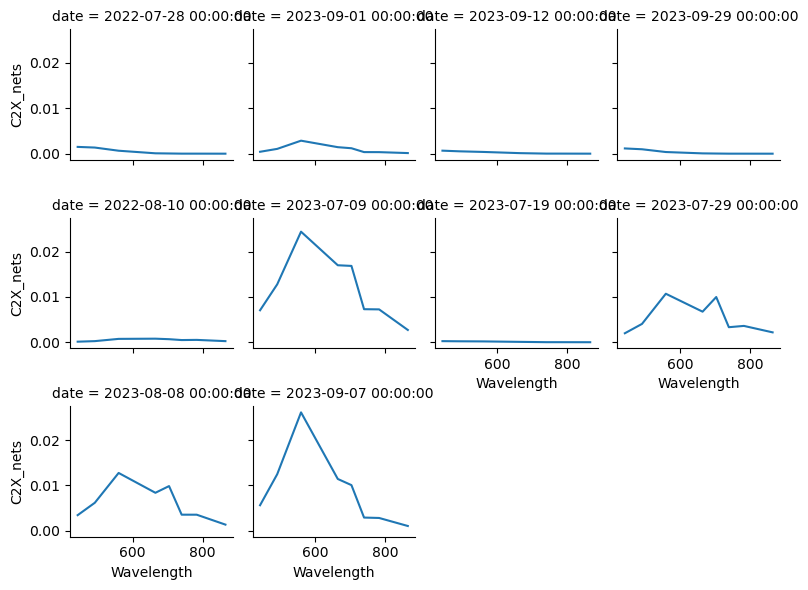

In [50]:
sns.relplot(data=dalec_S2_c2rcX,
            x='Wavelength', y='C2X_nets', col='date',
            col_wrap=4, kind='line', height=2)

<Axes: xlabel='Wavelength', ylabel='C2RCC_nets'>

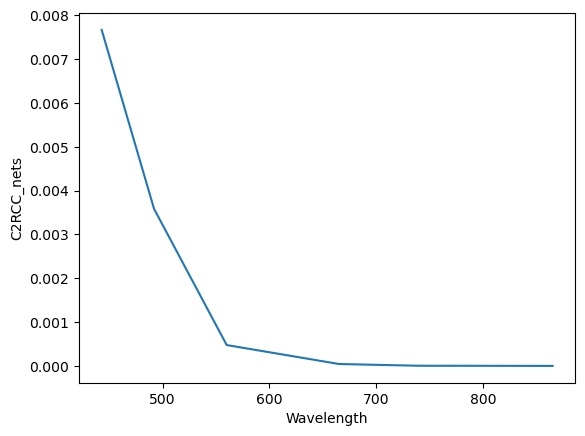

In [51]:
sns.lineplot(data=dalec_S2_c2rcc[dalec_S2_c2rcc.date=='2023-09-12'],
             x='Wavelength', y='C2RCC_nets')

In [52]:
dalec_S2_c2rcc[dalec_S2_c2rcc.date=='2023-09-29']

,Wavelength,date,Rrs_DALEC,Date,C2RCC_nets,original_date,date_flag
3,443.0,2023-09-29,0.000183,2023-09-29 11:33:19.023999,0.002916,nan,0.0
7,492.0,2023-09-29,0.001823,2023-09-29 11:33:19.023999,0.002342,nan,0.0
11,560.0,2023-09-29,0.003457,2023-09-29 11:33:19.023999,0.000685,nan,0.0
15,665.0,2023-09-29,0.002610,2023-09-29 11:33:19.023999,0.000073,nan,0.0
19,704.0,2023-09-29,0.002497,2023-09-29 11:33:19.023999,0.00004,nan,0.0
23,740.0,2023-09-29,0.001364,2023-09-29 11:33:19.023999,0.00001,nan,0.0
27,783.0,2023-09-29,0.001134,2023-09-29 11:33:19.023999,0.000009,nan,0.0
31,865.0,2023-09-29,0.001384,2023-09-29 11:33:19.023999,0.000003,nan,0.0


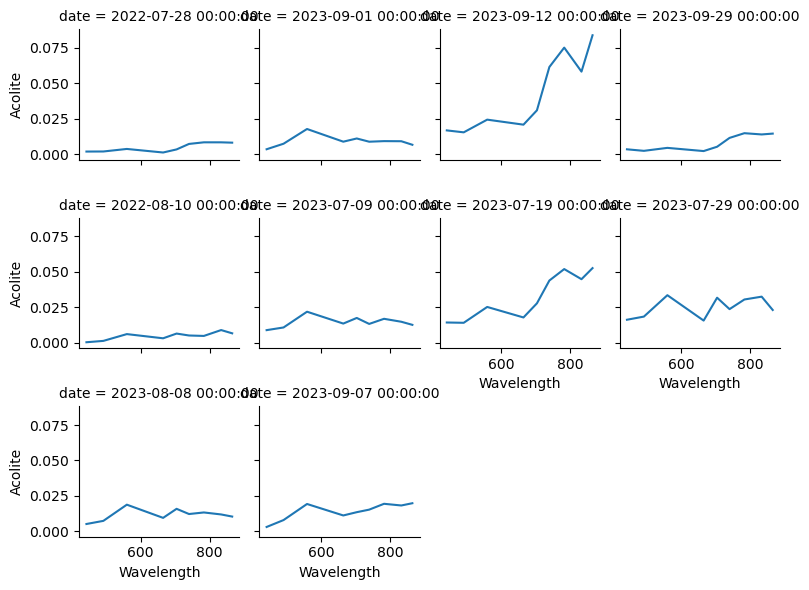

In [53]:
sns.relplot(data=dalec_S2_acolite,
            x='Wavelength', y='Acolite', col='date',
            col_wrap=4, kind='line', height=2)

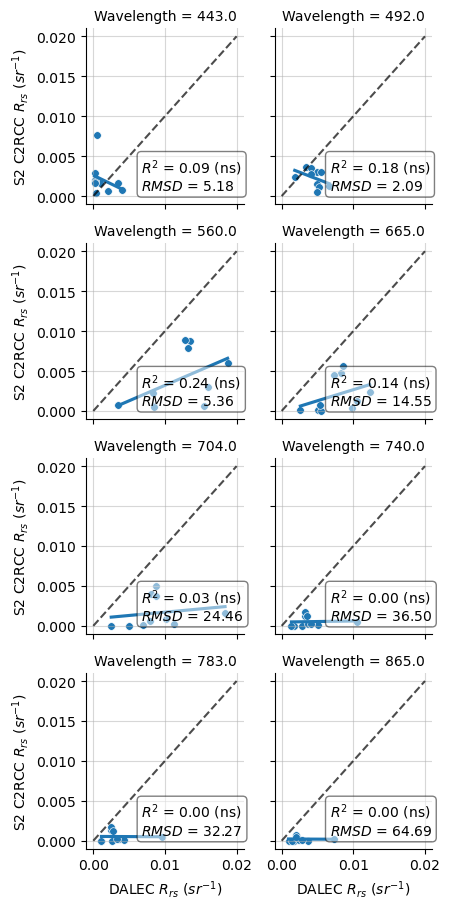

In [54]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    X = np.array(data.dropna()[x], dtype=float)
    Y = np.array(data.dropna()[y], dtype=float)
    res = sp.stats.linregress(X**order, Y)
#     mae = MAE(X, Y)
#     mape = MAPE(X, Y)
    rmsd = RMSD(X, Y)
#     bias = SSPB(X, Y)
#     mad = MAD(data.dropna()[x], data.dropna()[y])
#     mapd = MAPD(data.dropna()[x], data.dropna()[y])
#     mdsa = MDSA(data.dropna()[x], data.dropna()[y])
#     print('\nwavelength = ' + str(data.Wavelength.unique()))
#     print('MAE: '+ str(mae))
#     print('MAPE: ' + str(mape))
#     print('RMSD: ' + str(rmsd))
#     print('bias: ' + str(bias))
#     print('MAD: ' + str(mad))
#     print('MAPD: ' + str(mapd))
#     print('MDSA: ' + str(mdsa))
#     print('R2: ' + str(res.rvalue**2))
#     print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_c2rcc[dalec_S2_c2rcc.C2RCC_nets!=0], col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='C2RCC_nets', ci=None, scatter=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='C2RCC_nets',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='C2RCC_nets', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.02], [0, 0.02], 'k--', alpha=0.7)
#     ax.set_xlim(0, 0.02)
#     ax.set_ylim(.3e-3, 0.02)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 C2RCC $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




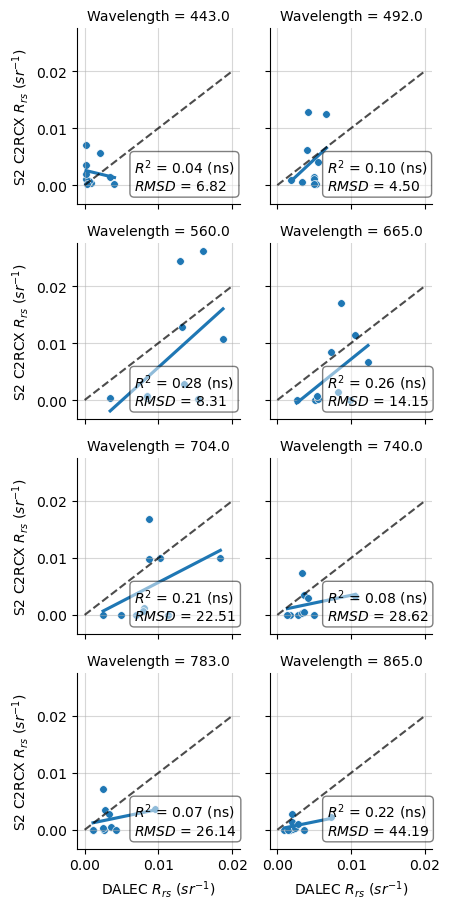

In [55]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    X = np.array(data.dropna()[x], dtype=float)
    Y = np.array(data.dropna()[y], dtype=float)
    res = sp.stats.linregress(X**order, Y)
#     mae = MAE(data.dropna()[x], data.dropna()[y])
#     mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(X, Y)
#     bias = SSPB(data.dropna()[x], data.dropna()[y])
#     mad = MAD(data.dropna()[x], data.dropna()[y])
#     mapd = MAPD(data.dropna()[x], data.dropna()[y])
#     mdsa = MDSA(data.dropna()[x], data.dropna()[y])
#     print('\nwavelength = ' + str(data.Wavelength.unique()))
#     print('MAE: '+ str(mae))
#     print('MAPE: ' + str(mape))
#     print('RMSD: ' + str(rmsd))
#     print('bias: ' + str(bias))
#     print('MAD: ' + str(mad))
#     print('MAPD: ' + str(mapd))
#     print('MDSA: ' + str(mdsa))
#     print('R2: ' + str(res.rvalue**2))
#     print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_c2rcX[dalec_S2_c2rcX.C2X_nets!=0], col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='C2X_nets', ci=None, scatter=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='C2X_nets',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='C2X_nets', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.02], [0, 0.02], 'k--', alpha=0.7)
#     ax.set_xlim(0, 0.02)
#     ax.set_ylim(.3e-3, 0.02)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 C2RCX $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


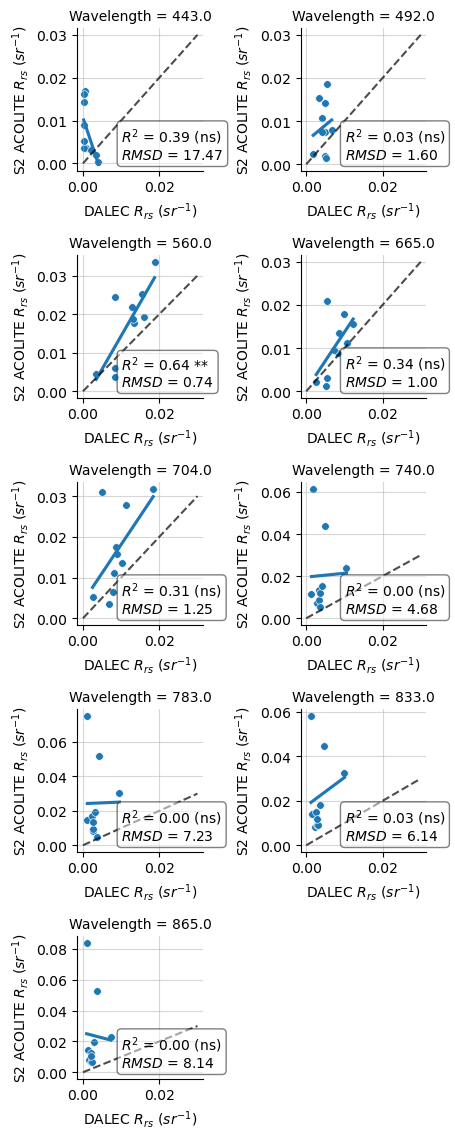

In [56]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    X = np.array(data.dropna()[x], dtype=float)
    Y = np.array(data.dropna()[y], dtype=float)
    res = sp.stats.linregress(X**order, Y)
#     mae = MAE(data.dropna()[x], data.dropna()[y])
#     mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(X, Y)
#     bias = SSPB(data.dropna()[x], data.dropna()[y])
#     mad = MAD(data.dropna()[x], data.dropna()[y])
#     mapd = MAPD(data.dropna()[x], data.dropna()[y])
#     mdsa = MDSA(data.dropna()[x], data.dropna()[y])
#     print('\nwavelength = ' + str(data.Wavelength.unique()))
#     print('MAE: '+ str(mae))
#     print('MAPE: ' + str(mape))
#     print('RMSD: ' + str(rmsd))
#     print('bias: ' + str(bias))
#     print('MAD: ' + str(mad))
#     print('MAPD: ' + str(mapd))
#     print('MDSA: ' + str(mdsa))
#     print('R2: ' + str(res.rvalue**2))
#     print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_acolite, col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='Acolite', ci=None, scatter=False, sharey=False, sharex=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Acolite',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Acolite', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.03], [0, 0.03], 'k--', alpha=0.7)
#     ax.set_xlim(.3e-3, 0.06)
#     ax.set_ylim(.3e-3, 0.06)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 ACOLITE $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


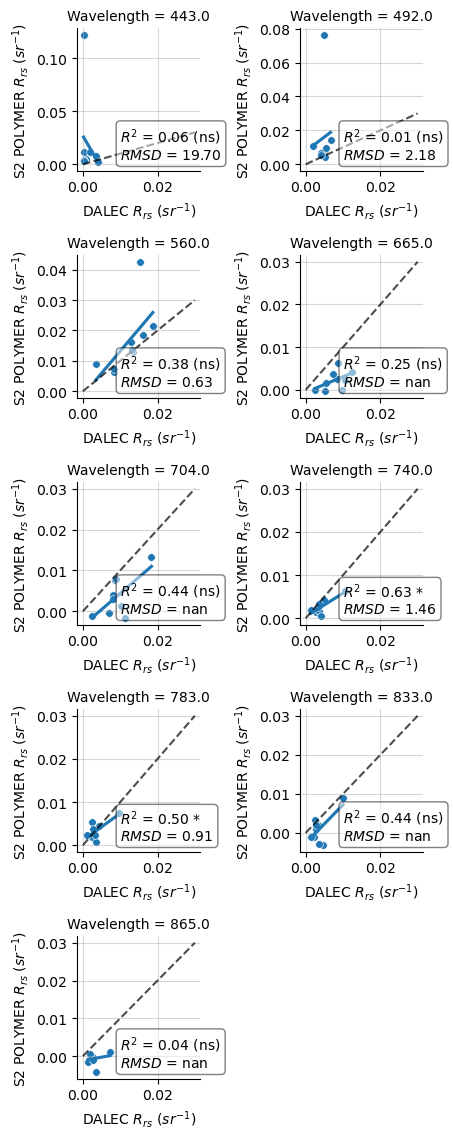

In [155]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    X = np.array(data.dropna()[x], dtype=float)
    Y = np.array(data.dropna()[y], dtype=float)
    res = sp.stats.linregress(X**order, Y)
#     mae = MAE(data.dropna()[x], data.dropna()[y])
#     mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(X, Y)
#     bias = SSPB(data.dropna()[x], data.dropna()[y])
#     mad = MAD(data.dropna()[x], data.dropna()[y])
#     mapd = MAPD(data.dropna()[x], data.dropna()[y])
#     mdsa = MDSA(data.dropna()[x], data.dropna()[y])
#     print('\nwavelength = ' + str(data.Wavelength.unique()))
#     print('MAE: '+ str(mae))
#     print('MAPE: ' + str(mape))
#     print('RMSD: ' + str(rmsd))
#     print('bias: ' + str(bias))
#     print('MAD: ' + str(mad))
#     print('MAPD: ' + str(mapd))
#     print('MDSA: ' + str(mdsa))
#     print('R2: ' + str(res.rvalue**2))
#     print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_polymer, col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='Polymer', ci=None, scatter=False,
               sharey=False, sharex=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Polymer',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Polymer', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.03], [0, 0.03], 'k--', alpha=0.7)
#     ax.set_xlim(.3e-3, 0.06)
#     ax.set_ylim(.3e-3, 0.06)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 POLYMER $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




# Where does this leave me?

- acolite currently still looks best
- I should use IDEPIX for mask though?
- need to think about what to do with masks / flags from atmospheric correction:
    - eg. Polymer produces some -ve Rrs
    - Polymer also has 'masked elements..' - could disable this and just use IDEPIX
    - C2RCX is better than C2RCC... what about C2X-COMPLEX_nets?
    - C2RCC settings?
    - what does C2RCC Rrs==0 mean?
        - think these are cases where the valid pixel expression has returned false
        - I'm running C2RCX with this disabled to see how this affects results!
    - Polymer settings?
    - generally hard to understand why S2 isn't working well...
        - could be worth trying pixels further from the shore?
- think I should also do some more checks to make sure that my processing chain is working fully
    - ie. check Rrs values in SNAP?


In [156]:
dalec_S2_polymer.date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-29 00:00:00',
 '2022-08-10 00:00:00', '2023-07-09 00:00:00', '2023-07-19 00:00:00',
 '2023-07-29 00:00:00', '2023-08-08 00:00:00', '2023-09-07 00:00:00']
Length: 9, dtype: datetime64[ns]

In [157]:
dalec_S2_c2rcX.date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00', '2022-08-10 00:00:00', '2023-07-09 00:00:00',
 '2023-07-19 00:00:00', '2023-07-29 00:00:00', '2023-08-08 00:00:00',
 '2023-09-07 00:00:00']
Length: 10, dtype: datetime64[ns]

In [158]:
dalec_S2_acolite.date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00', '2022-08-10 00:00:00', '2023-07-09 00:00:00',
 '2023-07-19 00:00:00', '2023-07-29 00:00:00', '2023-08-08 00:00:00',
 '2023-09-07 00:00:00']
Length: 10, dtype: datetime64[ns]

In [57]:
for df in [dalec_S2_acolite, dalec_S2_polymer, dalec_S2_c2rcc, dalec_S2_c2rcX, dalec_S2_c2rcc_CX]:
    df.drop('Date', axis=1, inplace=True)

In [58]:
on = ['date', 'Wavelength', 'Rrs_DALEC', 'original_date', 'date_flag']
how='outer'
dalec_S2_combo = dalec_S2_acolite.merge(dalec_S2_c2rcX,
                                        on=on,
                                        how=how).merge(dalec_S2_c2rcc,
                                                       on=on,
                                                       how=how).merge(dalec_S2_polymer,
                                                                      on=on,
                                                                      how=how).merge(dalec_S2_c2rcc_CX,
                                                                                      on=on,
                                                                                      how=how)
dalec_S2_combo

,Wavelength,date,Rrs_DALEC,Acolite,original_date,date_flag,C2X_nets,C2RCC_nets,Polymer,C2X_COMPLEX_nets
0,443.0,2022-07-28,0.003404,0.001898,2022-07-29,1.0,0.001499,0.001574,0.007720,0.002901
1,443.0,2023-09-01,0.000871,0.003524,2023-09-02,1.0,0.000425,0.00158,0.004496,0.001416
2,443.0,2023-09-12,0.000529,0.016816,nan,0.0,0.000670,0.007666,NaN,0.000588
3,443.0,2023-09-29,0.000183,0.003478,nan,0.0,0.001160,0.002916,0.011377,0.001150
4,492.0,2022-07-28,0.004902,0.001947,2022-07-29,1.0,0.001356,0.001538,0.007425,0.003531
...,...,...,...,...,...,...,...,...,...,...
85,865.0,2023-07-09,0.001983,0.012666,nan,0.0,0.002709,0.00068,0.000464,0.001172
86,865.0,2023-07-19,0.003648,0.052667,nan,0.0,0.000008,0.000028,-0.004278,0.000029
87,865.0,2023-07-29,0.007271,0.023138,nan,0.0,0.002181,0.000188,0.001175,0.001408
88,865.0,2023-08-08,0.001983,0.010432,nan,0.0,0.001366,0.000497,0.000487,0.000752


In [59]:
dalec_S2_combo[dalec_S2_combo.date_flag==1]

,Wavelength,date,Rrs_DALEC,Acolite,original_date,date_flag,C2X_nets,C2RCC_nets,Polymer,C2X_COMPLEX_nets
0,443.0,2022-07-28,0.003404,0.001898,2022-07-29,1.0,0.001499,0.001574,0.007720,0.002901
1,443.0,2023-09-01,0.000871,0.003524,2023-09-02,1.0,0.000425,0.00158,0.004496,0.001416
4,492.0,2022-07-28,0.004902,0.001947,2022-07-29,1.0,0.001356,0.001538,0.007425,0.003531
5,492.0,2023-09-01,0.004961,0.007416,2023-09-02,1.0,0.001063,0.003018,0.005652,0.002668
8,560.0,2022-07-28,0.008458,0.003738,2022-07-29,1.0,0.000657,0.000681,0.006213,0.002470
9,560.0,2023-09-01,0.013494,0.017810,2023-09-02,1.0,0.002870,0.008763,0.012837,0.007173
12,665.0,2022-07-28,0.005133,0.001230,2022-07-29,1.0,0.000088,0.000094,-0.000330,0.000182
13,665.0,2023-09-01,0.008261,0.008862,2023-09-02,1.0,0.001439,0.004787,0.002520,0.002662
16,704.0,2022-07-28,0.006931,0.003408,2022-07-29,1.0,0.000050,0.000052,-0.000495,0.000147
17,704.0,2023-09-01,0.008090,0.011118,2023-09-02,1.0,0.001203,0.003954,0.003932,0.003109


In [60]:
dalec_S2_combo_melt = pd.melt(dalec_S2_combo,
                              id_vars=on, value_vars=['Acolite', 'C2X_nets',
                                                      'C2RCC_nets', 'Polymer', 'C2X_COMPLEX_nets'],
                              var_name='Algorithm', value_name='Rrs')
dalec_S2_combo_melt

,date,Wavelength,Rrs_DALEC,original_date,date_flag,Algorithm,Rrs
0,2022-07-28,443.0,0.003404,2022-07-29,1.0,Acolite,0.001898
1,2023-09-01,443.0,0.000871,2023-09-02,1.0,Acolite,0.003524
2,2023-09-12,443.0,0.000529,nan,0.0,Acolite,0.016816
3,2023-09-29,443.0,0.000183,nan,0.0,Acolite,0.003478
4,2022-07-28,492.0,0.004902,2022-07-29,1.0,Acolite,0.001947
...,...,...,...,...,...,...,...
445,2023-07-09,865.0,0.001983,nan,0.0,C2X_COMPLEX_nets,0.001172
446,2023-07-19,865.0,0.003648,nan,0.0,C2X_COMPLEX_nets,0.000029
447,2023-07-29,865.0,0.007271,nan,0.0,C2X_COMPLEX_nets,0.001408
448,2023-08-08,865.0,0.001983,nan,0.0,C2X_COMPLEX_nets,0.000752


In [61]:
dalec_S2_combo_melt[dalec_S2_combo_melt.date.isin(dalec_S2_combo_melt[dalec_S2_combo_melt.Rrs==0.1218957014734188].date)]

,date,Wavelength,Rrs_DALEC,original_date,date_flag,Algorithm,Rrs
38,2023-07-19,443.0,0.000320,nan,0.0,Acolite,0.014316
44,2023-07-19,492.0,0.004962,nan,0.0,Acolite,0.014111
50,2023-07-19,560.0,0.015387,nan,0.0,Acolite,0.025286
56,2023-07-19,665.0,0.009826,nan,0.0,Acolite,0.01787
62,2023-07-19,704.0,0.011248,nan,0.0,Acolite,0.027839
68,2023-07-19,740.0,0.005018,nan,0.0,Acolite,0.043911
74,2023-07-19,783.0,0.004216,nan,0.0,Acolite,0.051992
80,2023-07-19,833.0,0.004581,nan,0.0,Acolite,0.044853
86,2023-07-19,865.0,0.003648,nan,0.0,Acolite,0.052667
128,2023-07-19,443.0,0.000320,nan,0.0,C2X_nets,0.000246


In [62]:
dalec_S2_combo_melt.Rrs.max()

0.1218957014734188

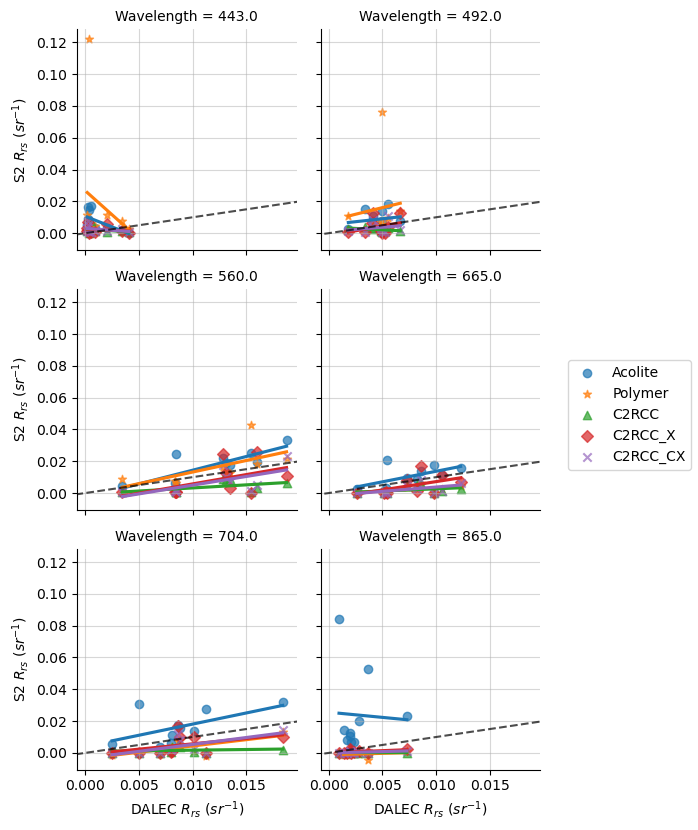

In [63]:
g = sns.lmplot(data=dalec_S2_combo_melt[~dalec_S2_combo_melt.Wavelength.isin([740., 783., 833.])],
               x='Rrs_DALEC', y='Rrs',
               hue='Algorithm',
               hue_order=['Acolite', 'Polymer',
                          'C2RCC_nets', 'C2X_nets', 'C2X_COMPLEX_nets'],
               col='Wavelength', col_wrap=2,
               scatter=True,
               markers=['o', '*', '^', 'D', 'x'],
               facet_kws={'sharey':True, 'sharex':True},
               scatter_kws={#'s':30,
                            'alpha':0.7},
               legend=False,
               ci=None,
               height=3.5)

# g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs',
#                 #style='Sat_ID',
#                 #hue='year',
#                 legend=True,
#                 #style='date',
#                 s=30, alpha=0.7)


for ax in g.axes.flat[:]:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(lims, lims, 'k--', alpha=0.7)
#     ax.set_xlim(-0.001, 0.02)
#     ax.set_ylim(-0.005, 0.05)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 $R_{rs}$ ($sr^{-1}$)')
    
handles, labels = ax.get_legend_handles_labels()
# print(labels)

g.figure.legend(labels=['Acolite', 'Polymer', 'C2RCC', 'C2RCC_X',  'C2RCC_CX'],
                handles=[h for h in handles[::1]],
               loc='center right')
plt.tight_layout(rect=[0.0, 0.0, 0.8, 0.8])
# rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
plt.show()

In [166]:
dalec_S2_combo_melt

,date,Wavelength,Rrs_DALEC,original_date,date_flag,Algorithm,Rrs
0,2022-07-28,443.0,0.003404,2022-07-29,1.0,Acolite,0.001898
1,2023-09-01,443.0,0.000871,2023-09-02,1.0,Acolite,0.003524
2,2023-09-12,443.0,0.000529,nan,0.0,Acolite,0.016816
3,2023-09-29,443.0,0.000183,nan,0.0,Acolite,0.003478
4,2022-07-28,492.0,0.004902,2022-07-29,1.0,Acolite,0.001947
...,...,...,...,...,...,...,...
445,2023-07-09,865.0,0.001983,nan,0.0,C2X_COMPLEX_nets,0.001172
446,2023-07-19,865.0,0.003648,nan,0.0,C2X_COMPLEX_nets,0.000029
447,2023-07-29,865.0,0.007271,nan,0.0,C2X_COMPLEX_nets,0.001408
448,2023-08-08,865.0,0.001983,nan,0.0,C2X_COMPLEX_nets,0.000752


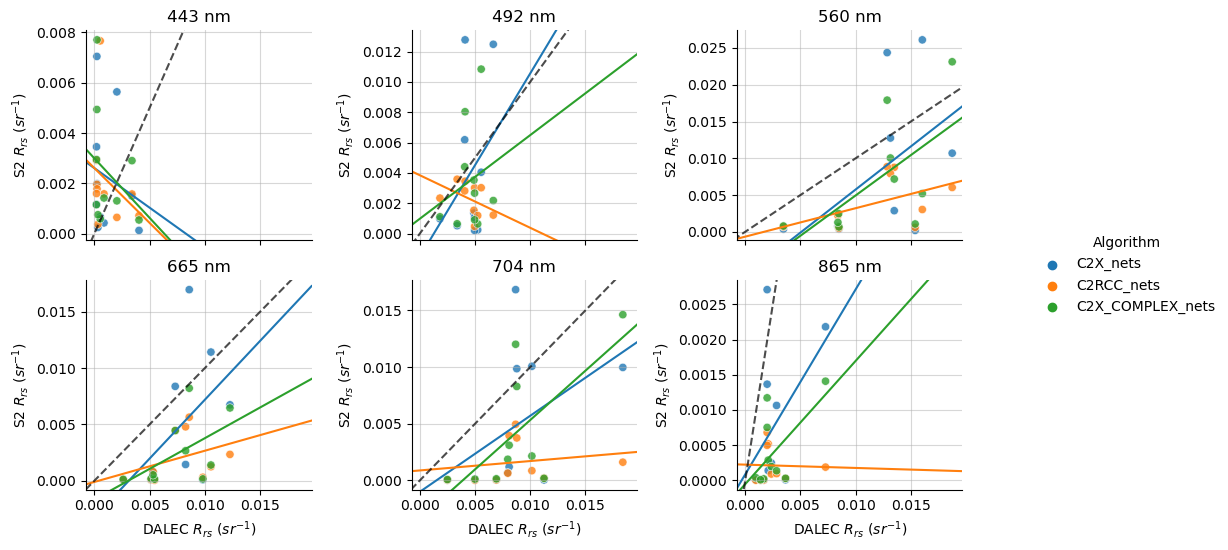

In [169]:
g = sns.relplot(data=dalec_S2_combo_melt[~dalec_S2_combo_melt.Wavelength.isin([740., 783., 833.])&\
                                        (dalec_S2_combo_melt.Algorithm.isin(['C2RCC_nets',
                                                                             'C2X_COMPLEX_nets',
                                                                             'C2X_nets']))],
                x='Rrs_DALEC', y='Rrs',
                hue='Algorithm', col='Wavelength', col_wrap=3,
                facet_kws={'sharey':False, 'sharex':True},
                alpha=0.8,
                height=3.5)

def annotate(data, x='Rrs_DALEC', y='Rrs', order=1, plot=True, lims=None, **kws):
    for alg, color in zip(data.Algorithm.unique(), sns.color_palette()):
        data_in = data[data.Algorithm==alg]
        res = sp.stats.linregress(np.array((data_in.dropna()[x]).values**order, dtype=float),
                                  np.array(data_in.dropna()[y].values, dtype=float))
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        m = res.slope
        c = res.intercept
        if plot:
            ax.plot(xlim, (np.array(xlim) * m) + c, color=color)
            ax.set_xlim(xlim[0], xlim[1])
            ax.set_ylim(ylim[0], ylim[1])
    
g.map_dataframe(annotate)


# g.map_dataframe(sns.lmplot, x='Rrs_DALEC', y='Rrs',
#                 ci=None, scatter=False, hue='Algorithm')

titles = ['443 nm', '492 nm', '560 nm', '665 nm', '704 nm', '865 nm']

for ax, title in zip(g.axes.flat[:], titles):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(lims, lims, 'k--', alpha=0.7)
#     ax.set_xlim(xlim[0], xlim[1])
#     ax.set_ylim(ylim[0], 0.045)#ylim[1])
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 $R_{rs}$ ($sr^{-1}$)')
    ax.set_title(title)
    
plt.tight_layout(rect=[0.0, 0.0, 0.8, 0.8])
plt.savefig('figures_for_paper/S2_DALEC_C2RCC.svg', dpi=300)



In [ ]:
sp.stats.linregress([0.00340373, 0.0008707,  0.00052867, 0.00018347, 0.00404201, 0.00022642,
 0.00031974, 0.00024074, 0.00019386, 0.0020382 ],
[0.0014993902295827866,0.0004252022481523454, 0.0006700038211420178,
 0.001160413259640336, 0.0001269954809686169, 0.007047399878501892,
 0.0002455058565828949, 0.001982902642339468 ,0.003452867269515991,
 0.005637190770357847])

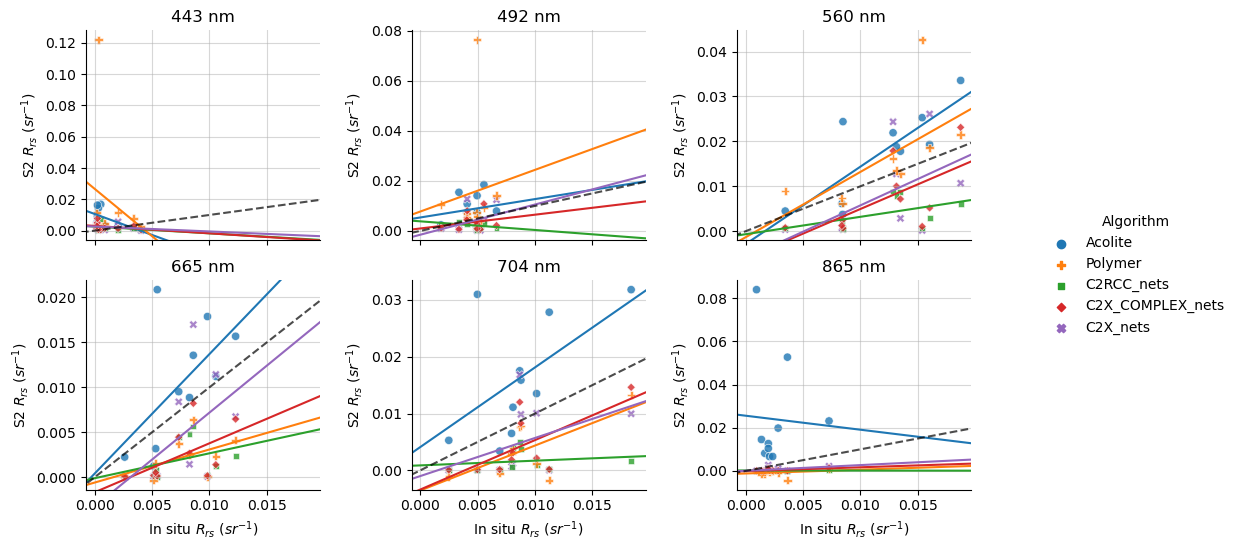

In [262]:
ORD = ['Acolite', 'Polymer', 'C2RCC_nets',
       'C2X_COMPLEX_nets', 'C2X_nets']
g = sns.relplot(data=dalec_S2_combo_melt[(~dalec_S2_combo_melt.Wavelength.isin([740., 783., 833.]))# &\
#                                         (dalec_S2_combo_melt.Algorithm.isin(['Acolite',
#                                                                              'C2X_COMPLEX_nets',
#                                                                              'Polymer']))
                                        ],
                x='Rrs_DALEC', y='Rrs',
                hue='Algorithm', col='Wavelength', col_wrap=3,
                hue_order=ORD,
                style='Algorithm',
                facet_kws={'sharey':False, 'sharex':True},
                alpha=0.8,
                height=3.5)

ls = ['-','--',':','-.','-','--',':','-.','-','--',]

def annotate(data, x='Rrs_DALEC', y='Rrs', order=1, plot=True, lims=None, **kws):
    for alg, color in zip(ORD, sns.color_palette()):
        data_in = data[data.Algorithm==alg]
        res = sp.stats.linregress(np.array((data_in.dropna()[x]).values**order, dtype=float),
                                  np.array(data_in.dropna()[y].values, dtype=float))
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        m = res.slope
        c = res.intercept
        if plot:
            ax.plot(xlim, (np.array(xlim) * m) + c, color=color,)
            ax.set_xlim(xlim[0], xlim[1])
            ax.set_ylim(ylim[0], ylim[1])
    
g.map_dataframe(annotate)


# g.map_dataframe(sns.lmplot, x='Rrs_DALEC', y='Rrs',
#                 ci=None, scatter=False, hue='Algorithm')
titles = ['443 nm', '492 nm', '560 nm', '665 nm', '704 nm', '865 nm']
for ax, title in zip(g.axes.flat[:], titles):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(lims, lims, 'k--', alpha=0.7)
#     ax.set_xlim(xlim[0], xlim[1])
#     ax.set_ylim(ylim[0], 0.045)#ylim[1])
    ax.grid(alpha=0.5)
    ax.set_xlabel('In situ $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 $R_{rs}$ ($sr^{-1}$)')
    ax.set_title(title)

    
plt.tight_layout(rect=[0.0, 0.0, 0.8, 0.8])
# plt.savefig('figures_for_paper/S2_DALEC_2.svg', dpi=300)



[-0.004, 0.01]
[-0.004, 0.01]
[-0.004, 0.052]
[-0.004, 0.023]
[-0.004, 0.05]
[-0.04, 0.012]


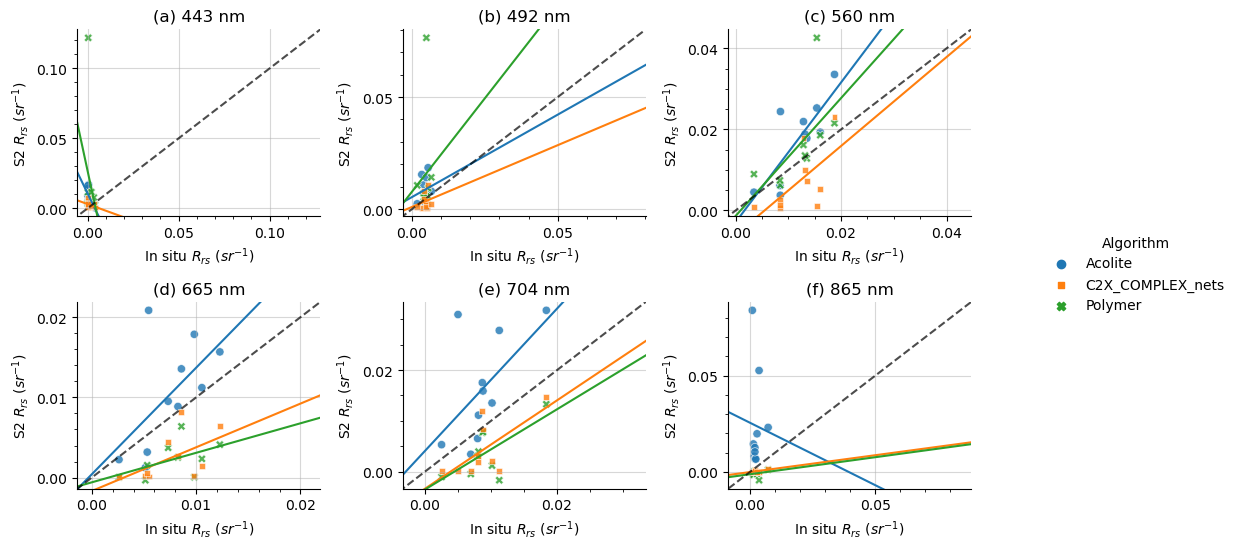

In [105]:
ORD = ['Acolite',  #'C2RCC_nets',
       'C2X_COMPLEX_nets','Polymer', #'C2X_nets'
      ]
g = sns.relplot(data=dalec_S2_combo_melt[(~dalec_S2_combo_melt.Wavelength.isin([740., 783., 833.])) &\
                                        (dalec_S2_combo_melt.Algorithm.isin(['Acolite',
                                                                             'C2X_COMPLEX_nets',
                                                                             'Polymer']))
                                        ],
                x='Rrs_DALEC', y='Rrs',
                hue='Algorithm', col='Wavelength', col_wrap=3,
                hue_order=ORD,
                style='Algorithm',
                facet_kws={'sharey':False, 'sharex':False},
                alpha=0.8,
                height=3.5)

ls = ['-','--',':','-.','-','--',':','-.','-','--',]

def annotate(data, x='Rrs_DALEC', y='Rrs', order=1, plot=True, lims=None, **kws):
    for alg, color in zip(ORD, sns.color_palette()):
        data_in = data[data.Algorithm==alg]
        res = sp.stats.linregress(np.array((data_in.dropna()[x]).values**order, dtype=float),
                                  np.array(data_in.dropna()[y].values, dtype=float))
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]

        m = res.slope
        c = res.intercept
        if plot:
            ax.plot(lims, (np.array(lims) * m) + c, color=color,)
            ax.set_xlim(lims[0], lims[1])
            ax.set_ylim(lims[0], lims[1])
    
g.map_dataframe(annotate)


# g.map_dataframe(sns.lmplot, x='Rrs_DALEC', y='Rrs',
#                 ci=None, scatter=False, hue='Algorithm')

xlims = [[-0.004, 0.01],[-0.004, 0.01],[-0.004, 0.052],[-0.004, 0.023],[-0.004, 0.05],[-0.04, 0.012]]
ylims = [[-0.004, 0.13],[-0.004, 0.08],[-0.004, 0.052],[-0.004, 0.023],[-0.004, 0.05],[-0.04, 0.12]]


titles = ['(a) 443 nm', '(b) 492 nm', '(c) 560 nm', '(d) 665 nm', '(e) 704 nm', '(f) 865 nm']
for ax, title, xlim, ylim in zip(g.axes.flat[:], titles, xlims, ylims):

#     xlim = ax.get_xlim()
#     ylim = ax.get_ylim()
    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(lims, lims, 'k--', alpha=0.7)
    print(xlim)
#     ax.set_xlim(xlim)
#     ax.set_ylim(ylim)

#     ax.set_ylim(0, lims[1]*1.1)
#     ax.set_xlim(xlim[0], xlim[1])
#     ax.set_ylim(ylim[0], 0.045)#ylim[1])
    ax.locator_params(axis='y', nbins=3)
    ax.locator_params(axis='x', nbins=3)
    ax.grid(alpha=0.5)
    ax.set_xlabel('In situ $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 $R_{rs}$ ($sr^{-1}$)')
    ax.set_title(title)
#     ax.set_xticks(ax.get_yticks())

    ax.minorticks_on()
    


g.fig.subplots_adjust(hspace=0.8, wspace=.8)

plt.tight_layout(rect=[0.0, 0.0, 0.8, 0.8])
plt.savefig('figures_for_paper/S2_DALEC_2_update.svg', dpi=300)

In [174]:
np.max([[1, 2], [3, 1]], axis=0)

array([3, 2])

In [180]:
def r2_rmse(g):
    try:
        X = np.array(g.dropna()['Rrs_DALEC'], dtype=float)
        Y = np.array(g.dropna()['Rrs'], dtype=float)
        r2 = sp.stats.pearsonr(X, Y)[0]**2
        slope = sp.stats.linregress(X, Y).slope
        rmse = np.sqrt(mean_squared_error(X, Y))
        mape = MAPE(X, Y)
        mrd = MRD(X, Y)
        mavd = MAvD(X, Y)
        mapd = MAPD(X, Y)

        return pd.Series(dict(r2 = r2,
                              slope=slope,
                              rmse = rmse,
                              mape=mape,
                              mrd=mrd,
                              mapd=mapd,
                              mavd=mavd
                                        ))
    except ValueError:
        return pd.Series(dict(r2 = np.nan,
                              slope=np.nan, 
                              rmse = np.nan,
                              mape=np.nan,
                              mrd=np.nan,
                              mapd=np.nan,
                              mavd=np.nan
                                          ))

In [181]:
metrics = dalec_S2_combo_melt.groupby(['Wavelength', 'Algorithm']).apply(r2_rmse).reset_index()

In [182]:
metrics

,Wavelength,Algorithm,r2,slope,rmse,mape,mrd,mapd,mavd
0,443.0,Acolite,0.386128,-2.677315,0.009236,2281.910104,22.550063,2185.788726,0.006185
1,443.0,C2RCC_nets,0.090497,-0.435637,0.002874,526.515930,4.856338,360.754960,0.000875
2,443.0,C2X_COMPLEX_nets,0.087619,-0.473488,0.003161,747.239587,7.197451,110.561454,0.001219
3,443.0,C2X_nets,0.035843,-0.314478,0.003054,638.029639,5.925918,136.717439,0.001020
4,443.0,Polymer,0.055925,-6.048714,0.040916,5537.959458,55.288976,1490.142657,0.017653
5,492.0,Acolite,0.026583,0.735736,0.006961,125.488818,0.985823,78.086225,0.004168
6,492.0,C2RCC_nets,0.177191,-0.346349,0.002997,48.358567,-0.414713,42.369626,-0.002298
7,492.0,C2X_COMPLEX_nets,0.044618,0.551157,0.003409,63.007353,-0.231596,74.010410,-0.001069
8,492.0,C2X_nets,0.104431,1.209177,0.004472,85.091544,-0.148981,81.544661,-0.000580
9,492.0,Polymer,0.009227,1.667705,0.024199,254.445306,2.498496,68.866945,0.010870


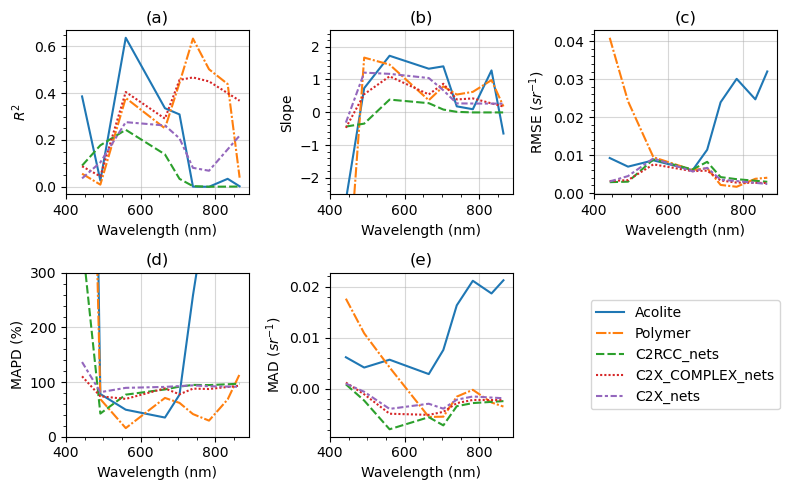

In [255]:
fig, axs = plt.subplots(2, 3, figsize=(8, 5), sharex=False)
ORD = ['Acolite', 'Polymer', 'C2RCC_nets',
       'C2X_COMPLEX_nets', 'C2X_nets']

metrs = ['r2', 'slope', 'rmse', 'mapd', 'mavd']
metrs_labels = ['$R^2$', 'Slope', 'RMSE ($sr^{-1}$)', 'MAPD (%)', 'MAD ($sr^{-1}$)']

for ax, met in zip(axs.flatten(), metrs):
    sns.lineplot(data=metrics, x='Wavelength', y=met, hue='Algorithm', style='Algorithm',
                 ax=ax, legend=False, hue_order=ORD)

axs.flatten()[-1].set_axis_off()
axs.flatten()[3].set_ylim(0, 300)
axs.flatten()[1].set_ylim(-2.5, 2.5)


axs.flatten()[-1].legend(axs.flatten()[-2].get_lines(), ORD,
                         loc='center')

for ax, lab, titl in zip(axs.flatten(), metrs_labels, ['(a)', '(b)', '(c)', '(d)', '(e)']):
    ax.minorticks_on()
    ax.grid(alpha=0.5)
    ax.set_ylabel(lab)
    ax.set_xlim(400, 890)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_title(titl)


    
plt.tight_layout()
plt.savefig('figures_for_paper/S2_atmos_corr_metrics.svg', dpi=300)


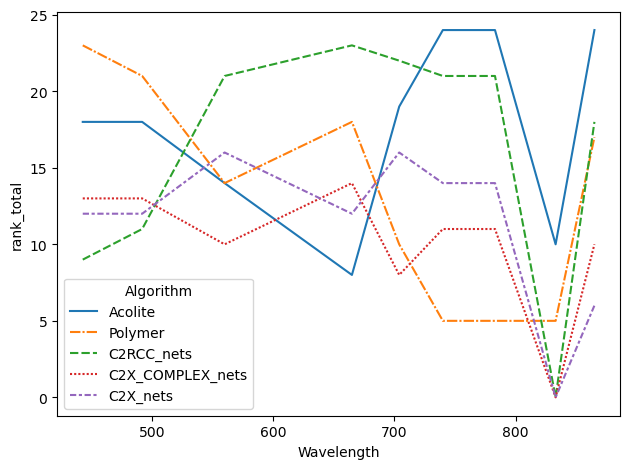

In [261]:
# fig, axs = plt.subplots(2, 3, figsize=(8, 5), sharex=False)
ORD = ['Acolite', 'Polymer', 'C2RCC_nets',
       'C2X_COMPLEX_nets', 'C2X_nets']

metrs = ['rank_total']
metrs_labels = ['$R^2$', 'Slope', 'RMSE ($sr^{-1}$)', 'MAPD (%)', 'MAD ($sr^{-1}$)']


sns.lineplot(data=metrics, x='Wavelength', y='rank_total', hue='Algorithm', style='Algorithm',
#                  ax=ax,
             legend=True, hue_order=ORD)

axs.flatten()[-1].set_axis_off()
axs.flatten()[3].set_ylim(0, 300)
axs.flatten()[1].set_ylim(-2.5, 2.5)


axs.flatten()[-1].legend(axs.flatten()[-2].get_lines(), ORD,
                         loc='center')

for ax, lab, titl in zip(axs.flatten(), metrs_labels, ['(a)', '(b)', '(c)', '(d)', '(e)']):
    ax.minorticks_on()
    ax.grid(alpha=0.5)
    ax.set_ylabel(lab)
    ax.set_xlim(400, 890)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_title(titl)


    
plt.tight_layout()
# plt.savefig('figures_for_paper/S2_atmos_corr_metrics.svg', dpi=300)


In [183]:
metrics.to_csv('S2_atmos_corr_metrics_out_20m__sdf.csv')

In [184]:
metrics['r2_1'] = 1 - metrics.r2
metrics['slope_1'] = np.abs(1 - metrics.slope)
metrics['mard'] = np.abs(metrics.mrd)
metrics['abs_mavd'] = np.abs(metrics.mavd)


In [185]:
for metr in [
            'r2_1',
             'slope_1',
             'mapd',
             'abs_mavd',
             'rmse']:
    metrics[metr+'_rank'] = metrics.groupby(['Wavelength',])[metr].rank('min')

metrics

metrics['rank_total'] = metrics[['r2_1_rank',
                                 'slope_1_rank',
                                 'mapd_rank',
                                 'rmse_rank',
                                 'abs_mavd_rank']].sum(axis=1)

In [186]:
metrics.groupby(['Algorithm']).rank_total.sum()

Algorithm
Acolite             159.0
C2RCC_nets          146.0
C2X_COMPLEX_nets     90.0
C2X_nets            102.0
Polymer             118.0
Name: rank_total, dtype: float64

## here I've just formalised how we really determine which algorithms are best

- idea is to rank for each metric and each wavelength
- then sum ranks for each algorithm and each wavelength
- then choose best ranking (lowest no.) algorithm for each wavelength
- the results of this align with my intuitions more or less, which is good!

In [ ]:
best_ranks = metrics.dropna().groupby('Wavelength')['rank_total'].idxmin()
metrics.loc[best_ranks]

In [ ]:
metrics.dropna().groupby('Algorithm').slope_1_rank.median() + metrics.dropna().groupby('Algorithm').r2_1_rank.median()

In [ ]:
metrics.dropna().groupby('Algorithm').rank_total.mean()

In [ ]:
# find best rmse algs
metrics.loc[metrics.groupby('Wavelength').rmse.agg('idxmin')]

In [ ]:
# find best mape algs 
metrics.loc[metrics.groupby('Wavelength').mape.agg('idxmin')]

In [ ]:
# find best r2 algs 
metrics.loc[metrics.groupby('Wavelength').r2.agg('idxmax')]

# where I'm at now

MASKS (maybe rerun and work out how disable all masking?)
- have applied IDEPix mask
- for c2rcX, the default valid pix thingy is disabled
- for c2rcc valid pix is being used as default
- for polymer I'm using standard settings, which I think includes some masking
- for acolite, I'm using the modified l2w mask (with high threshold for land masking)

Which seems best?
- Polymer seems best at the greens, reds
- c2rcc for blues?

NEXT STEPS:
- decide a sensible masking approach (only idepix? or combine idepix and others?)
    - if I choose only IDEPIX then I'd need to:
        - rerun acolite to get l2R not L2W (that disables masking completely)
        - rerun c2rcc with masking disabled
        - work out how to get non-masked values from Polymer output
    - I think the best approach is:
        - use l2R from acolite (avoid land masking)
        - accept the default mask from polymer?
        - disable c2rcc valid mask because this is based on a band 8 threshold
            - should do this for regular c2rcc
                - now integrated into this analysis
    - try the other c2rcc (complex X)?
        - this is now done and integrated into this analysis
- decide metrics properly (Warren, Spyrakos paper?)
    - warren paper: https://www.sciencedirect.com/science/article/pii/S0034425719301099
    - uses: R2, MAPE, RMSE, mean relative difference
    - I think this seems like a good suite for atmospheric correction checking
    - would make sense to do logspace versions of these for chl-a I think though
- decide approach (i.e. do I just choose best overall, or use different correction for different bands?)
    - I think different correction for different bands is a good idea! 
        - really we want to get the best possible from S2, and I think given there isn't a single correction method which stands out for all bands, a hybrid approach is very justifiable. To be fair, I should probably do this for Planet too
- get Planet SR data for comparison with acolite
    - this has been completed, and checked in another notebook: `Planet SR test`


# to summarise where I'm at now (04 - June 2024)

- think my atmospheric correction procedure makes sense
- now need to ascertain which alg to use for each wavelength
    - make some nice tables
- then integrate this into the chl-a analysis


In [ ]:
# Now try to get full S2 data into a df 

In [ ]:
# make sure all Dates are same format:

for df in [S2_c2rcc_med, S2_c2rcX_med, S2_c2rcc_CX_med, S2_polymer_med, S2_acolite_med]:
    df.Date = pd.to_datetime(df.Date, utc=True)

In [ ]:
on_cols = ['date', 'Wavelength', 'date_flag', 'original_date']

S2_total_med = S2_c2rcc_med.drop('Date', axis=1).merge(S2_acolite_med.drop('Date', axis=1),
                                                       on=on_cols).merge(S2_polymer_med.drop('Date', axis=1),
                                                       on=on_cols).merge(S2_c2rcX_med.drop('Date', axis=1),
                                                       on=on_cols).merge(S2_c2rcc_CX_med.drop('Date', axis=1),
                                                       on=on_cols)

In [ ]:
S2_total_med

In [ ]:
# set s2a and s2b wavelengths to be the same
S2_total_med['Wavelength'] = S2_total_med.Wavelength.apply(nearest_wavelength,
                                                           args=[metrics.Wavelength.unique()])

In [ ]:
S2_total_med.Wavelength.unique()

In [ ]:
S2_total_med['best_alg'] = ''
for Wavelength, alg in zip(metrics.loc[best_ranks].Wavelength,
                           metrics.loc[best_ranks].Algorithm): 
    print(Wavelength)

    S2_total_med.loc[S2_total_med.Wavelength==Wavelength, 'best_alg'] = alg
    


In [ ]:
def get_best(df):
    return df[df['best_alg']]

In [ ]:
S2_total_med['Rrs_best'] = S2_total_med.apply(get_best, axis=1)

In [ ]:
S2_total_med

In [ ]:
S2_total_med.to_csv('Sentinel_2_best_atmos_corr_med_56.147005__3.923311_NNNNEWWW.csv')